In [52]:
from pathlib import Path
from common.jsonl import read_df
from common.plots import ecdf, histograms, by_distance, summarise, small_groups

### Load

> NOTE: only one run was completed when this was written so the `run` filter is not here

In [74]:
df, _ = read_df(Path("../data/tokens/data.jsonl"))
df.head(2)

,v,run,ts,tool,args,args_sha,tokens,chars,err,encoding,commit,dirty
0,0,tok-3700e95,2026-08-18T15:43:51.769105+00:00,crags_near,"{'place': 'Squamish', 'maxDistanceKm': 5}",b937484532de,1807,4861,False,o200k_base,3700e952de8d54ee34f5ace901869b4e121ecb0a,False
1,0,tok-3700e95,2026-08-18T15:43:53.099157+00:00,crags_near,"{'place': 'Squamish', 'maxDistanceKm': 20}",e0f22780e799,1807,4861,False,o200k_base,3700e952de8d54ee34f5ace901869b4e121ecb0a,False


In [76]:
df["place"] = df["args"].apply(lambda a: a.get("place"))
df["km"] = df["args"].apply(lambda a: a.get("maxDistanceKm"))
fan = df.dropna(subset=["km"])

wide = fan.pivot_table(index=["tool", "place"], columns="km", values="tokens")
(wide[5.0] == wide[50.0]).groupby(level="tool").agg(["sum", "size"])


,sum,size
tool,,
crags_near,36,48
find_climbs,43,48


In [77]:
rt = read_df(Path("../data/tokens/roundtrips.jsonl"))[0]
joined = df.merge(rt[["tool", "args_sha", "roundtrips", "ms"]], on=["tool", "args_sha"])
joined.groupby(["tool", "km"])[["tokens", "roundtrips"]].median()


tokens  roundtrips
tool        km                      
crags_near  5.0     32.0         1.0
            20.0   796.0        14.0
            50.0   796.0        14.0
find_climbs 5.0     40.0         1.0
            20.0    40.0        14.0
            50.0    40.0        14.0

In [54]:
summarise(df, "tool")          # n, mean, p50/p90/p95/p99, max, fails

,n,mean,p50,p90,p95,p99,max,fails
tool,,,,,,,,
crags_near,144,842.479167,117.5,1922.0,1996.85,2282.00,2282,0
find_climbs,144,968.326389,40.0,3541.7,3745.00,3773.00,3773,1
get_area_details,69,1300.826087,852.0,2630.0,3614.60,6658.76,6688,0


In [55]:
df[df.err == True]

,v,run,ts,tool,args,args_sha,tokens,chars,err,encoding,commit,dirty
265,0,tok-3700e95,2026-08-18T15:47:39.205599+00:00,find_climbs,"{'place': 'Fair Head', 'maxDistanceKm': 20, 'm...",155e397023d6,0,76,True,o200k_base,3700e952de8d54ee34f5ace901869b4e121ecb0a,False


## Clean

In [56]:
df.commit.unique(), df.dirty.unique(), df.encoding.unique(), df.run.unique(), df.v.unique()

(array(['3700e952de8d54ee34f5ace901869b4e121ecb0a'], dtype=object),
 array([False]),
 array(['o200k_base'], dtype=object),
 array(['tok-3700e95'], dtype=object),
 array([0]))

In [57]:
df.err.unique()

array([False,  True])

Remove constant columns and useless ones

In [58]:
df.drop(columns=["commit","dirty", "encoding", "run", "v", "args_sha"], inplace=True)

In [59]:
df.head(2)

,ts,tool,args,tokens,chars,err
0,2026-08-18T15:43:51.769105+00:00,crags_near,"{'place': 'Squamish', 'maxDistanceKm': 5}",1807,4861,False
1,2026-08-18T15:43:53.099157+00:00,crags_near,"{'place': 'Squamish', 'maxDistanceKm': 20}",1807,4861,False


### `crags_near`

In [60]:
crags_near = df[df.tool == "crags_near"]
crags_near.shape[0]

144

In [61]:
crags_near["max_distance"] = crags_near.args.apply(lambda x: x["maxDistanceKm"])
crags_near["place"] = crags_near.args.apply(lambda x: x["place"])
crags_near.drop("args", inplace=True, axis=1)

/tmp/ipykernel_143936/1838280637.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crags_near["max_distance"] = crags_near.args.apply(lambda x: x["maxDistanceKm"])
/tmp/ipykernel_143936/1838280637.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crags_near["place"] = crags_near.args.apply(lambda x: x["place"])
/tmp/ipykernel_143936/1838280637.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/

In [ ]:
crags_near[(crags_near.tokens > 1000) & (crags_near.place == "Squamish")]

,ts,tool,tokens,chars,err,max_distance,place
0,2026-08-18T15:43:51.769105+00:00,crags_near,1807,4861,False,5,Squamish
1,2026-08-18T15:43:53.099157+00:00,crags_near,1807,4861,False,20,Squamish
2,2026-08-18T15:43:54.373149+00:00,crags_near,1807,4861,False,50,Squamish


In [82]:
crags_near[(crags_near.tokens > 1000) & (crags_near.place == "Canmore")]

,ts,tool,tokens,chars,err,max_distance,place
3,2026-08-18T15:43:55.250017+00:00,crags_near,1921,5276,False,5,Canmore
4,2026-08-18T15:43:56.333618+00:00,crags_near,1921,5276,False,20,Canmore
5,2026-08-18T15:43:58.737125+00:00,crags_near,1921,5276,False,50,Canmore


In [83]:
crags_near[(crags_near.tokens > 1000) & (crags_near.place == "Banff")]

,ts,tool,tokens,chars,err,max_distance,place
6,2026-08-18T15:43:59.643835+00:00,crags_near,1085,2900,False,5,Banff
7,2026-08-18T15:44:00.491852+00:00,crags_near,1755,4666,False,20,Banff
8,2026-08-18T15:44:01.790629+00:00,crags_near,1755,4666,False,50,Banff


#### Why is this bimodal?
Squamish, Canmore, Banff
- For distances 5, 20, 50km the token usage is the same?


Reason?
1. There is nothing returned for some areas in the gazzetteer
2. There are too many results returned from places like Squamish where climbs are so abundant, that the distance filter is useless

Potential Solutions:
1. Prune areas so that all of them return results
2. Increase max number of crags

In [ ]:
wide = crags_near.pivot_table(
    index=["tool", "place"],
    columns="max_distance",
    values="tokens",
)
(wide[5.0] == wide[50.0]).groupby(level="tool").agg(["sum", "size"])

,sum,size
tool,,
crags_near,36,48


In [78]:
wide["identical"] = wide[5.0] == wide[50.0]
# a proxy for hitting the cap, since payload size tracks the list length
wide.groupby(wide[5.0] > wide[5.0].median())["identical"].mean()


5.0
False    0.77551
True     0.87234
Name: identical, dtype: float64

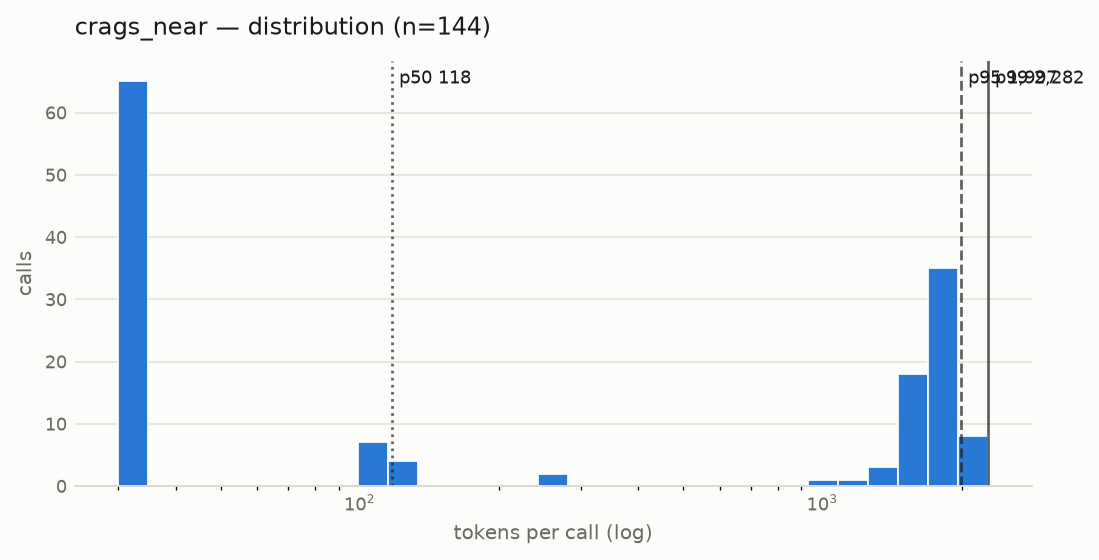

In [64]:
h = histograms(crags_near)

### `find_climbs`

In [80]:
find_climbs=df[df.tool=="find_climbs"]

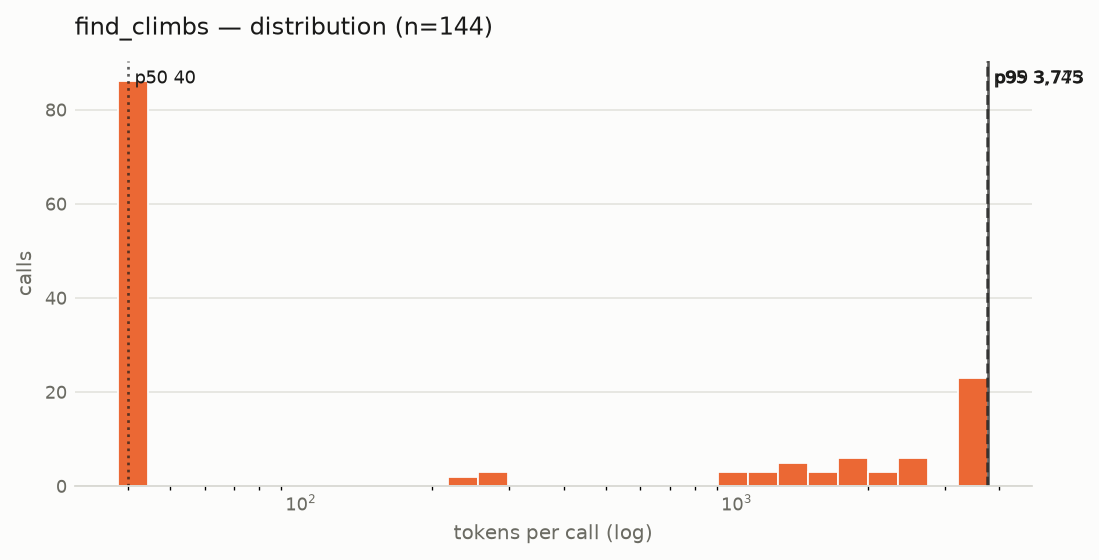

In [81]:
h = histograms(find_climbs)

A similar story here 

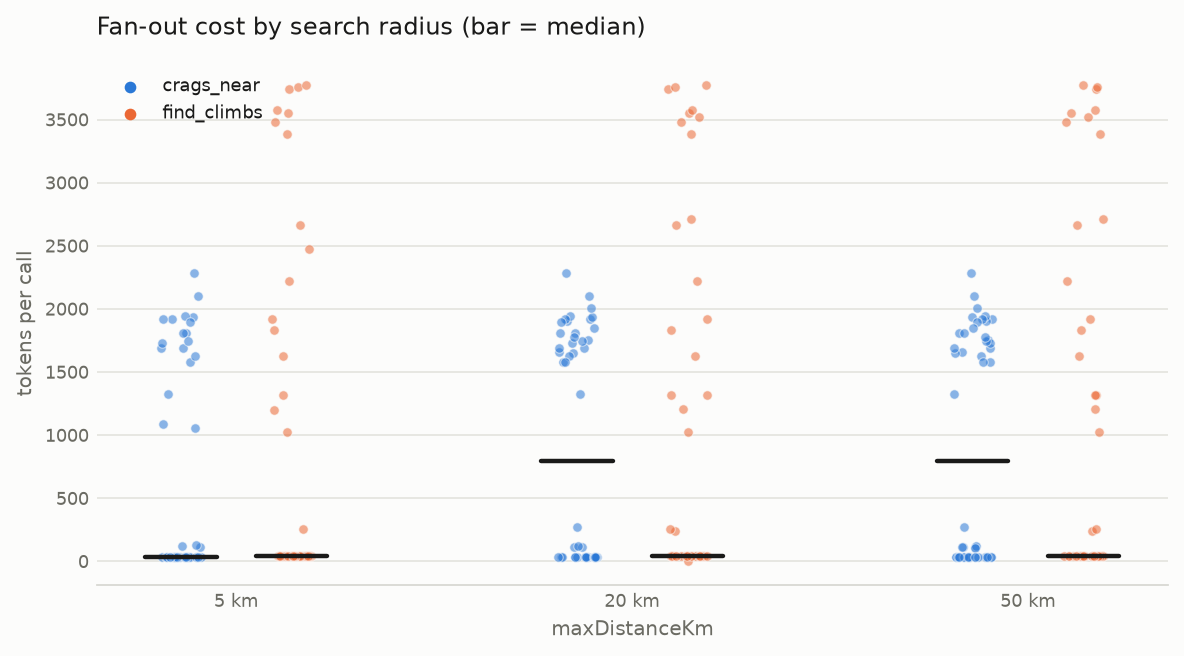

In [12]:
d=by_distance(df)